# Assignment Boosting and Stacking

In [1]:
# Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.

In [2]:
# Answer:- Boosting is an ensemble learning technique in machine learning that combines multiple weak learners (models that perform slightly better than random guessing) to form a strong learner with high accuracy.
           #It works by training weak models sequentially, where each new model focuses more on the data points that were misclassified by previous models. 
           #By assigning higher weights to difficult examples and combining all weak models using weighted voting or summation, boosting effectively reduces both bias and variance, leading to improved overall performance. 
           #Examples include AdaBoost, Gradient Boosting, and XGBoost.

In [3]:
# Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?

In [4]:
# Answer:- The main difference between AdaBoost and Gradient Boosting lies in how they train weak learners and update errors.
            #AdaBoost (Adaptive Boosting) updates sample weights after each weak learner is trained. Misclassified samples get higher weights so that the next model focuses more on them. 
            #It combines models based on their classification accuracy.
            #Gradient Boosting, on the other hand, builds models by minimizing a loss function using gradient descent.
            #Each new model is trained to predict the residual errors (gradients) of the previous models, gradually improving the overall prediction.

In [5]:
# Question 3: How does regularization help in XGBoost?

In [6]:
# Answer:- Regularization in XGBoost helps to prevent overfitting and improve the model’s generalization by penalizing complex models. It adds a regularization term to the loss function that controls the complexity of the trees.
           #XGBoost uses both L1 (Lasso) and L2 (Ridge) regularization:
           #L1 regularization (on leaf weights) encourages sparsity, removing unnecessary features.
           #L2 regularization smooths the model by penalizing large leaf weights.

In [7]:
# Question 4: Why is CatBoost considered efficient for handling categorical data?

In [8]:
# Answer:- CatBoost is considered efficient for handling categorical data because it automatically encodes categorical features using a method called Target Encoding with Ordered Statistics. Instead of simple one-hot encoding, 
           #CatBoost converts categorical values into numerical statistics (like average target values) in a way that prevents target leakage.
           #It also uses ordered boosting, which ensures that each model is trained only on past data, improving accuracy and reducing overfitting. These techniques allow CatBoost to handle categorical 
           #variables efficiently without extensive preprocessing and deliver strong performance even with raw categorical features.

In [9]:
# Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?

In [10]:
# Answer:- Boosting techniques are preferred over bagging methods in applications where high accuracy and handling complex patterns are crucial.
            #Some real-world examples include:
            #Fraud detection: Boosting can capture rare and complex patterns in transactional data.
            #Customer churn prediction: It improves prediction accuracy by focusing on hard-to-classify customers.
            #Medical diagnosis: Boosting models like XGBoost and LightGBM perform well on imbalanced and noisy datasets.
            #Credit scoring: It effectively models non-linear relationships in financial data.
            #Search ranking and recommendation systems: Used by companies like Google and Netflix for ranking relevance.

# Coding Questions

In [11]:
#Question 6: Write a Python program to:
#● Train an AdaBoost Classifier on the Breast Cancer dataset
#● Print the model accuracy

In [13]:
#Answer:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train AdaBoost model
model = AdaBoostClassifier(n_estimators=100, random_state=42,algorithm="SAMME")
model.fit(X_train, y_train)

# Predictions and accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 4))


Model Accuracy: 0.9737


In [14]:
#Question 7: Write a Python program to:
#● Train a Gradient Boosting Regressor on the California Housing dataset
#● Evaluate performance using R-squared score

In [16]:
#Answer
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load data
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)

# Evaluate
y_pred = gbr.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R-squared Score:", round(r2, 4))


R-squared Score: 0.8004


In [17]:
#Question 8: Write a Python program to:
#● Train an XGBoost Classifier on the Breast Cancer dataset
#● Tune the learning rate using GridSearchCV
#● Print the best parameters and accuracy

In [18]:
# Answer
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Load data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Base model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Parameter grid for learning rate
param_grid = {'learning_rate': [0.01, 0.05, 0.1, 0.2]}

# Grid search
grid = GridSearchCV(xgb, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", round(accuracy, 4))

C:\Users\admin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:25:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.1}
Best Accuracy: 0.9561


In [19]:
#Question 9: Write a Python program to:
#● Train a CatBoost Classifier
#● Plot the confusion matrix using seaborn

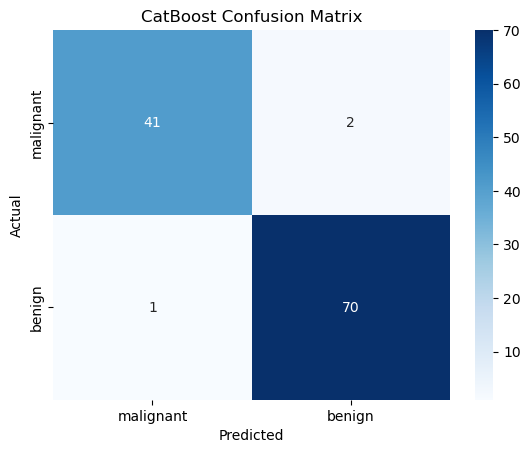

In [20]:
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)

# Predict
y_pred = cat_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
#Question 10: You're working for a FinTech company trying to predict loan default using
#customer demographics and transaction behavior.
#The dataset is imbalanced, contains missing values, and has both numeric and
#categorical features.
#Describe your step-by-step data science pipeline using boosting techniques:
#● Data preprocessing & handling missing/categorical values
#● Choice between AdaBoost, XGBoost, or CatBoost
#● Hyperparameter tuning strategy
#● Evaluation metrics you'd choose and why
#● How the business would benefit from your model

In [22]:
# Answer
#1. **Data Preprocessing**
#   - Handle missing values:
#     • Numeric: Use mean/median imputation
#     • Categorical: Use mode or a new “Unknown” category
#   - Encode categorical features:
#     • Label encoding or One-Hot encoding (XGBoost)
#     • CatBoost handles categorical variables directly.
#   - Scale numeric features using StandardScaler or MinMaxScaler.
#
#2. **Choice of Model**
#   - Since data is *imbalanced* and includes *categorical + numeric* features:
#     → **CatBoostClassifier** is ideal because:
#       • It handles categorical data natively.
#       • Robust to missing values.
#       • Performs well on imbalanced data with class weights.
#
#3. **Hyperparameter Tuning**
#   - Use GridSearchCV or RandomizedSearchCV on:
#     • learning_rate, depth, n_estimators, l2_leaf_reg
#   - Use stratified 5-fold cross-validation for stability.

#4. **Evaluation Metrics**
#   - Accuracy alone is misleading for imbalanced data.
#   - Use:
#     • Precision, Recall, F1-Score
#     • AUC-ROC curve (primary metric)
#     • Confusion Matrix for interpretability

#5. **Business Impact**
#   - Helps identify high-risk customers early.
#   - Enables proactive measures like adjusting credit limits or requiring collateral.
#   - Reduces financial loss and improves credit decision-making.
